# EDA 07: Absolute Gene Copy Number

## Purpose

Most human cells normally carry two copies of each autosomal gene, one from each parent. Cancer cells often lose DNA sections or gain extra copies. Losing copies can reduce a gene's function; gaining many copies can increase gene activity. Cancer genomes are frequently abnormal overall, so a value of four copies may be a focal amplification in one model but close to the model's background ploidy in another.

This notebook studies absolute copy number and prepares transparent deletion/amplification context for conditional dependency.

## Decisions inherited from CRISPR and mutation EDA

- Copy number describes gene-A state; it is not evidence that gene B is a dependency.
- Define absence only in models with `has_absolute_copy_number=1`.
- Later conditional dependency uses only models with both alteration evidence and CRISPR measurements.
- Keep mutation and copy-number components separate before creating a combined alteration definition.
- Compare lineages and use threshold sensitivity instead of pretending one cutoff is universal.

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
sns.set_theme(style='whitegrid', context='notebook')

def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'data' / 'depmap_24Q4' / 'architecture' / 'model_master.csv').exists():
            return candidate
    raise FileNotFoundError('Run this notebook from inside the az-team25 repository.')

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATA = PROJECT_ROOT / 'data' / 'depmap_24Q4'

PATHS = {'master': DATA/'architecture'/'model_master.csv', 'copy_number': DATA/'raw'/'OmicsAbsoluteCNGene.csv'}
master = pd.read_csv(PATHS['master'], low_memory=False)
cn_columns = pd.read_csv(PATHS['copy_number'], nrows=0).columns.tolist()
print(f'Absolute-copy-number genes: {len(cn_columns)-1:,}')

Absolute-copy-number genes: 36,700


## Column dictionary

| Column | Plain-language meaning | Use in this project |
| --- | --- | --- |
| `Unnamed: 0` | DepMap `model_id`. | Only automatic model-level join key. |
| `<GENE> (Entrez ID)` | Estimated absolute number of DNA copies of that gene. | Detects gene loss or gain and helps define gene-A alteration. |

Absolute copy number is not the same as RNA expression. Extra DNA copies may increase RNA, but regulation and technical factors can weaken that relationship.

## 1. Matrix grain, coverage, and CRISPR overlap

The table is already one row per model. We verify model IDs and calculate the exact overlap needed for later conditional-dependency analysis.

In [2]:
cn_ids = pd.read_csv(PATHS['copy_number'], usecols=['Unnamed: 0'])['Unnamed: 0']
master_ids = set(master['model_id'])
crispr_ids = set(master.loc[master['has_crispr_gene_effect'].eq(1), 'model_id'])
mutation_ids = set(master.loc[master['has_mutation_assay'].eq(1), 'model_id'])
cn_set = set(cn_ids)
audit = pd.DataFrame([{
    'copy_number_models': cn_ids.nunique(), 'duplicate_model_ids': int(cn_ids.duplicated().sum()),
    'models_not_in_master': len(cn_set-master_ids),
    'copy_number_and_CRISPR_models': len(cn_set & crispr_ids),
    'copy_number_mutation_and_CRISPR_models': len(cn_set & mutation_ids & crispr_ids),
}])
display(audit)
assert cn_ids.is_unique and not (cn_set-master_ids)

,copy_number_models,duplicate_model_ids,models_not_in_master,copy_number_and_CRISPR_models,copy_number_mutation_and_CRISPR_models
0,1607,0,0,948,948


### What this means for the project

The overlap count is the maximum denominator for a mutation-plus-copy-number conditional-dependency test. Models outside it are not normal or non-dependent; one of the required measurements is simply unavailable.

## 2. Full-matrix copy-number audit

We scan the wide matrix in chunks. Values near zero or one suggest strong loss, while high values suggest gain, but these are exploratory descriptions until model ploidy is considered.

,count,mean,std,min,25%,50%,75%,max
mean_absolute_cn,1607.0,2.943595,0.790673,1.607985,2.117139,2.919716,3.543229,5.095779
genes_cn_le_1_pct,1607.0,2.345300,4.348048,0.000000,0.181199,0.686649,2.483651,49.765668
genes_cn_ge_4_pct,1607.0,27.158689,27.010174,0.000000,2.088556,19.294278,47.453678,99.476839


,count,mean,std,min,25%,50%,75%,max
mean_cn,36700.0,2.943595,0.320337,1.759003,2.751538,2.890684,3.078486,10.770341
sd_cn,36700.0,1.277697,0.794398,0.737850,1.008372,1.122803,1.338396,25.961209
cn_le_1_pct,36700.0,2.345300,2.309985,0.000000,0.871189,1.680149,2.986932,36.341008
cn_ge_4_pct,36700.0,27.158689,8.397371,8.774113,21.095208,25.700062,30.927194,60.734287


#### Genes with the most variable copy number

,feature,mean_cn,sd_cn,cn_le_1_pct,cn_ge_4_pct,gene
10213,MYCNOS (10408),5.770614,25.961209,0.995644,28.002489,MYCNOS
2123,MYCNUT (103752554),5.770925,25.961149,0.995644,28.002489,MYCNUT
23335,RN7SL104P (106480949),5.770925,25.961149,0.995644,28.002489,RN7SL104P
36594,MYCN (4613),5.770925,25.961149,0.995644,28.002489,MYCN
21967,RNU6-450P (106481321),3.876795,25.262755,0.435594,35.158681,RNU6-450P
324,GACAT3 (104797537),5.498087,23.982848,1.057872,27.878034,GACAT3
10337,RPLP1P5 (130678),5.410038,23.789836,0.995644,27.940261,RPLP1P5
30378,RNU5E-7P (100873836),5.410660,23.789733,0.933416,27.940261,RNU5E-7P
26363,MYC (4609),6.320458,19.576247,0.248911,50.404480,MYC
4838,CASC11 (100270680),6.128474,19.006185,0.311139,50.155569,CASC11


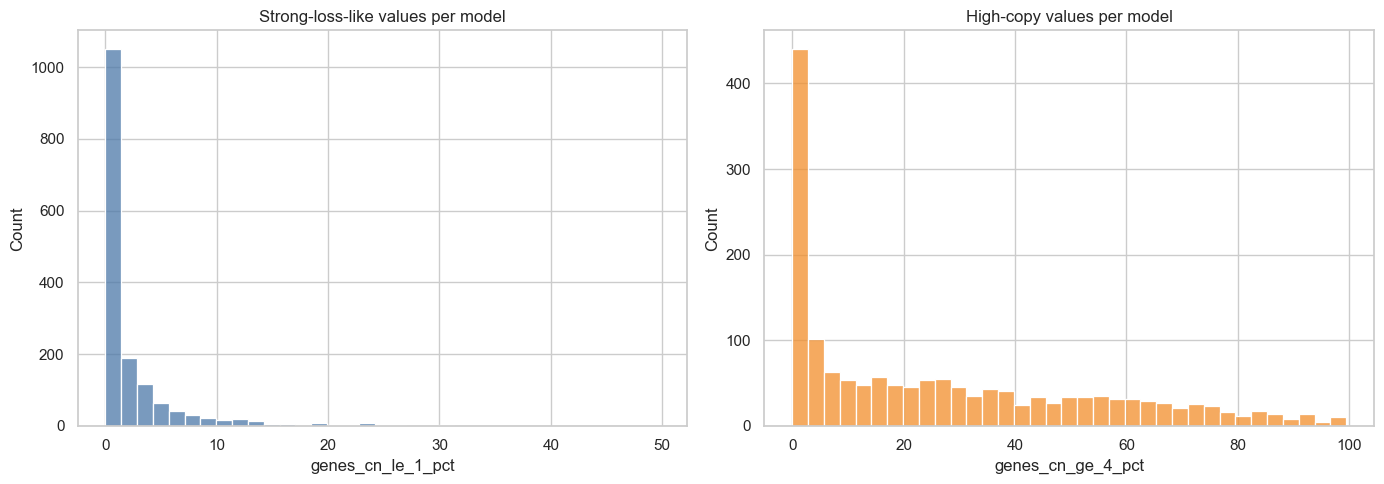

In [3]:
def summarise_cn(path, chunksize=64):
    columns = pd.read_csv(path, nrows=0).columns.tolist()
    n = len(columns)-1
    sums=np.zeros(n); sums_sq=np.zeros(n); counts=np.zeros(n,dtype=np.int64)
    loss=np.zeros(n,dtype=np.int64); gain=np.zeros(n,dtype=np.int64)
    model_rows=[]
    for chunk in pd.read_csv(path, chunksize=chunksize, low_memory=False):
        values=chunk.iloc[:,1:].to_numpy(dtype=np.float64,copy=False); valid=np.isfinite(values)
        sums+=np.nansum(values,axis=0); sums_sq+=np.nansum(values*values,axis=0); counts+=valid.sum(axis=0)
        loss+=(values<=1).sum(axis=0); gain+=(values>=4).sum(axis=0)
        model_rows.append(pd.DataFrame({'model_id':chunk.iloc[:,0].astype(str),'mean_absolute_cn':np.nanmean(values,axis=1),'genes_cn_le_1_pct':100*(values<=1).sum(axis=1)/valid.sum(axis=1),'genes_cn_ge_4_pct':100*(values>=4).sum(axis=1)/valid.sum(axis=1)}))
    means=sums/counts
    genes=pd.DataFrame({'feature':columns[1:],'mean_cn':means,'sd_cn':np.sqrt(np.maximum(sums_sq/counts-means**2,0)),'cn_le_1_pct':100*loss/counts,'cn_ge_4_pct':100*gain/counts})
    genes['gene']=genes['feature'].str.replace(r' \(\d+\)$','',regex=True)
    return pd.concat(model_rows,ignore_index=True),genes

cn_model_summary, cn_gene_summary = summarise_cn(PATHS['copy_number'])
display(cn_model_summary.describe().T)
display(cn_gene_summary[['mean_cn','sd_cn','cn_le_1_pct','cn_ge_4_pct']].describe().T)
display(Markdown('#### Genes with the most variable copy number'))
display(cn_gene_summary.nlargest(25,'sd_cn'))

fig,axes=plt.subplots(1,2,figsize=(14,5))
sns.histplot(cn_model_summary['genes_cn_le_1_pct'],bins=35,ax=axes[0],color='#4C78A8'); axes[0].set_title('Strong-loss-like values per model')
sns.histplot(cn_model_summary['genes_cn_ge_4_pct'],bins=35,ax=axes[1],color='#F28E2B'); axes[1].set_title('High-copy values per model')
plt.tight_layout(); plt.show()

### What this means for the project

A model with many genes above four copies may have duplicated much of its genome, rather than thousands of separate focal amplifications. This is why the next genomic-signature notebook must bring in ploidy, whole-genome duplication, chromosome instability, and aneuploidy before copy-number thresholds become features.

## 3. Example genes, lineage, and threshold sensitivity

We inspect familiar cancer genes and show how altered-model counts change under several transparent thresholds.

,count,mean,std,min,25%,50%,75%,max
ARID1A,1607.0,2.649969,0.945052,0.000000,2.0,2.0,3.0,8.000000
BRCA1,1607.0,2.967957,1.071742,1.000000,2.0,3.0,4.0,10.007131
BRCA2,1607.0,2.683933,1.136707,0.333333,2.0,2.0,3.0,14.504852
TP53,1607.0,2.528572,1.005452,0.000000,2.0,2.0,3.0,8.000000
CDKN2A,1607.0,1.759003,1.424760,0.000000,0.0,2.0,3.0,7.000000
RB1,1607.0,2.566923,1.101114,0.000000,2.0,2.0,3.0,8.000000
PTEN,1607.0,2.573127,0.968614,0.000000,2.0,2.0,3.0,7.000000
MYC,1607.0,6.320458,19.582341,1.000000,2.0,4.0,5.0,398.235227
ERBB2,1607.0,4.203198,11.572537,1.000000,2.0,3.0,4.0,250.259822
EGFR,1607.0,4.387866,11.149414,1.000000,2.0,3.0,4.0,331.367727


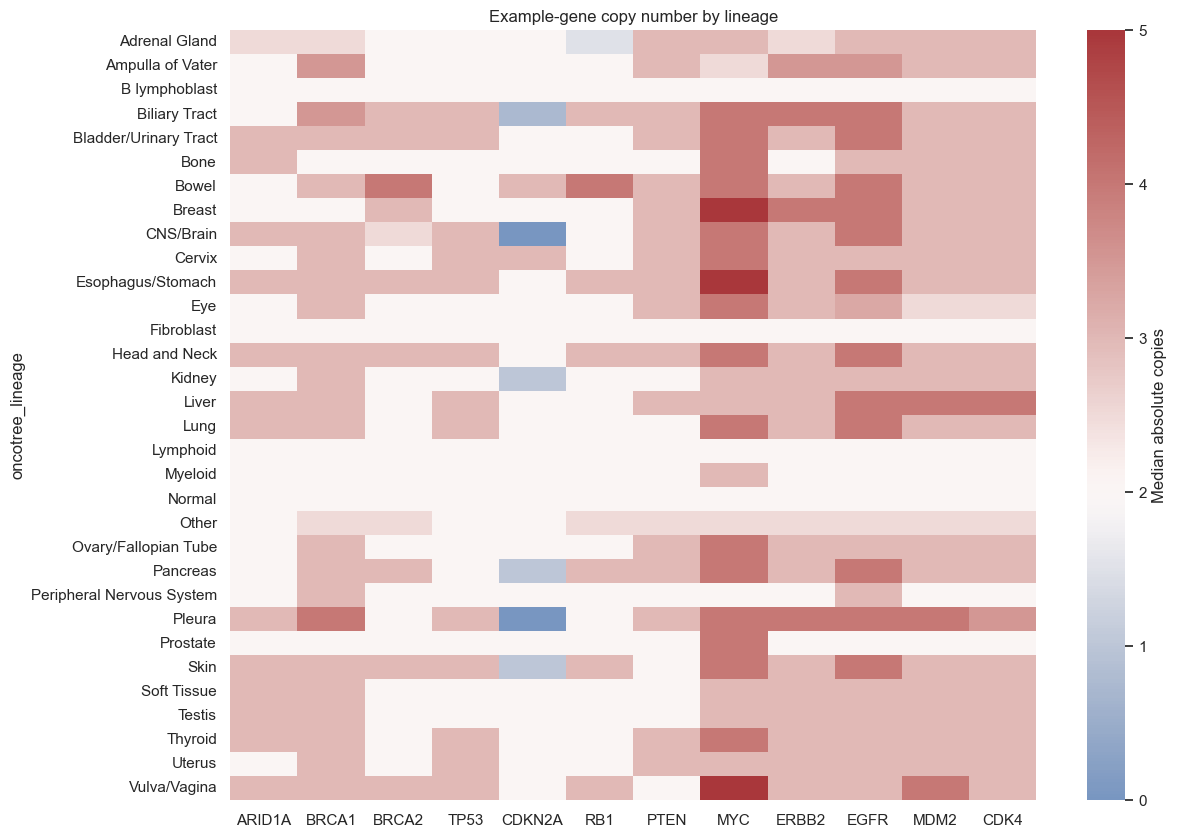

,gene,example_rule,models,denominator
0,ARID1A,deep-loss-like: CN < 0.5,3,1607
1,ARID1A,loss-like: CN <= 1,72,1607
2,ARID1A,gain-like: CN >= 4,286,1607
3,ARID1A,high-gain-like: CN >= 6,13,1607
4,BRCA1,deep-loss-like: CN < 0.5,0,1607
5,BRCA1,loss-like: CN <= 1,19,1607
6,BRCA1,gain-like: CN >= 4,468,1607
7,BRCA1,high-gain-like: CN >= 6,36,1607
8,BRCA2,deep-loss-like: CN < 0.5,1,1607
9,BRCA2,loss-like: CN <= 1,75,1607


In [4]:
PANEL=['ARID1A','BRCA1','BRCA2','TP53','CDKN2A','RB1','PTEN','MYC','ERBB2','EGFR','MDM2','CDK4']
def find_col(gene):
    matches=[c for c in cn_columns if c.startswith(f'{gene} (')]
    return matches[0] if len(matches)==1 else None
mapping={g:find_col(g) for g in PANEL}; mapping={g:c for g,c in mapping.items() if c}
panel=pd.read_csv(PATHS['copy_number'],usecols=['Unnamed: 0',*mapping.values()]).rename(columns={'Unnamed: 0':'model_id',**{v:k for k,v in mapping.items()}})
panel=panel.merge(master[['model_id','oncotree_lineage']],on='model_id',how='left',validate='one_to_one')
display(panel[list(mapping)].describe().T)

lineage_medians=panel.groupby('oncotree_lineage')[list(mapping)].median()
plt.figure(figsize=(13,10)); sns.heatmap(lineage_medians,cmap='vlag',center=2,cbar_kws={'label':'Median absolute copies'}); plt.title('Example-gene copy number by lineage'); plt.show()

rows=[]
for gene in mapping:
    for label,rule in [('deep-loss-like: CN < 0.5',panel[gene]<0.5),('loss-like: CN <= 1',panel[gene]<=1),('gain-like: CN >= 4',panel[gene]>=4),('high-gain-like: CN >= 6',panel[gene]>=6)]:
        rows.append({'gene':gene,'example_rule':label,'models':int(rule.sum()),'denominator':panel[gene].notna().sum()})
display(pd.DataFrame(rows))

### What this means for the project

For `CDKN2A`, a value near zero is much stronger loss evidence than a value just below two. For `ERBB2` or `MYC`, very high copies may support amplification. The notebook calls these example rules because background ploidy can change their meaning.

## Decisions carried into genomic-signature EDA

- Keep raw absolute copy number as a continuous feature and show threshold sensitivity for loss/gain flags.
- Define copy-number absence only inside the 1,607 measured models.
- Combine copy number with mutation status only through visible rules; retain each component separately.
- Restrict later alteration-versus-dependency tests to models with both copy number/mutation and CRISPR coverage.
- Carry lineage and per-model copy-number burden as context.
- Use ploidy and whole-genome duplication to decide whether a high copy number is focal-looking or part of a globally duplicated genome.